In [ ]:
!pip install transformers datasets
!pip install scikit-learn

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 491.2/491.2 kB 8.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 116.3/116.3 kB 4.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 183.9/183.9 kB 5.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 143.5/143.5 kB 8.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 194.8/194.8 kB 10.4 MB/s eta 0:00:00
  Attempting uninstall: fsspec
    Found existing installation: fsspec 2025.3.2
    Uninstalling fsspec-2025.3.2:
      Successfully uninstalled fsspec-2025.3.2
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
gcsfs 2025.3.2 requires fsspec==2025.3.2, but you have fsspec 2024.12.0 which is incompatible.
torch 2.6.0+cu124 requires nvidia-cublas-cu12==12.4.5.8; platform_system == "Linux" and platform_machine == "x86_64", but you have nvidia-cublas-cu12 12.5.3.2 which is 

In [ ]:
#import torch and the tokenizer
from transformers import BertTokenizer, BertModel
import torch



In [ ]:
from google.colab import files
uploaded = files.upload() #upload the files


Saving book32-listing.csv to book32-listing.csv


In [ ]:
filename = list(uploaded.keys())[0]

In [ ]:
# text cleansing
!pip install chardet #install and import chardet so we can open the csv file and convert into a dataframe


In [ ]:
import chardet

#find the encoding of the file to open the file and read from it
with open(filename, 'rb') as f:
    file_encoder = chardet.detect(f.read(10000))

with open(filename, encoding=file_encoder['encoding']) as f:
    files = f.readlines() #









In [ ]:
#Transform the CSV file to a pandas dataframe
import pandas as pd
import csv

columns = ['ASIN', 'FILENAME', 'IMAGE_URL', 'TITLE', 'AUTHOR', 'CATEGORY_ID', 'CATEGORY'] # assign the columns
dataset = [] # initialize array

with open(filename, encoding=file_encoder['encoding']) as f:
    reader = csv.reader(f)
    for row in reader: # to ensure there is no column mismatch we want to make sure every row has 7 columns
        if len(row) == 7:
            dataset.append(row) # add the row iff it has 7 columns

#print(dataset[0])
#print(dataset[1])
df = pd.DataFrame(dataset, columns=columns) # create the dataframe

#print only the first 3 rows
print(df.head(3))




         ASIN        FILENAME  \
0   761183272  0761183272.jpg   
1  1623439671  1623439671.jpg   
2  B00O80WC6I  B00O80WC6I.jpg   

                                           IMAGE_URL  \
0  http://ecx.images-amazon.com/images/I/61Y5cOdH...   
1  http://ecx.images-amazon.com/images/I/61t-hrSw...   
2  http://ecx.images-amazon.com/images/I/41X-KQqs...   

                                               TITLE          AUTHOR  \
0                    Mom's Family Wall Calendar 2016  Sandra Boynton   
1                    Doug the Pug 2016 Wall Calendar    Doug the Pug   
2  Moleskine 2016 Weekly Notebook, 12M, Large, Bl...       Moleskine   

  CATEGORY_ID   CATEGORY  
0           3  Calendars  
1           3  Calendars  
2           3  Calendars  


In [ ]:
#clean the text values so they will work for the BERT model
import string
def clean_text(text):
  text = text.lower().strip() # set the title name to lower case and and remove trailing spaces
  text = ''.join(c for c in text if c not in string.punctuation)

  return text

df['TITLE'] = df['TITLE'].apply(clean_text)
df['CATEGORY'] = df['CATEGORY'].apply(clean_text)

print(df.head(3))


         ASIN        FILENAME  \
0   761183272  0761183272.jpg   
1  1623439671  1623439671.jpg   
2  B00O80WC6I  B00O80WC6I.jpg   

                                           IMAGE_URL  \
0  http://ecx.images-amazon.com/images/I/61Y5cOdH...   
1  http://ecx.images-amazon.com/images/I/61t-hrSw...   
2  http://ecx.images-amazon.com/images/I/41X-KQqs...   

                                               TITLE          AUTHOR  \
0                     moms family wall calendar 2016  Sandra Boynton   
1                    doug the pug 2016 wall calendar    Doug the Pug   
2  moleskine 2016 weekly notebook 12m large black...       Moleskine   

  CATEGORY_ID   CATEGORY  
0           3  calendars  
1           3  calendars  
2           3  calendars  


In [ ]:
#generate the label for classification
from sklearn.preprocessing import LabelEncoder
encoder = LabelEncoder()
df['LABEL'] = encoder.fit_transform(df['CATEGORY']) # assign the numerical values to each catergory




In [ ]:
from sklearn.model_selection import train_test_split



In [ ]:
#Get the Bert tokenizer
#import transformers as ppb
#from transformers import BertTokenizer, BertModel
#import torch

#weights = 'distilbert-base-uncased'
#def get_tokenizer():
    #return ppb.DistilBertTokenizer.from_pretrained(weights)
#tokenizer = BertTokenizer.from_pretrained('bert-base-uncased')
#model = BertModel.from_pretrained('bert-base-uncased')

from transformers import DistilBertTokenizer, DistilBertModel
tokenizer = DistilBertTokenizer.from_pretrained('distilbert-base-uncased')
model = DistilBertModel.from_pretrained('distilbert-base-uncased')

#for this approach I will extract embeddings which are numeric represenetations of text that capture the meaning of the words
#then I will formulate the training and test sets based on these embeddings and use a Random Tree classifier to perform the classification
#This approach was meant to combat the issue that I was early with the BERT model.
#I was having isssues to get the BERT to run and generate accuracry, precison, recall, and fscores on the dataset
#when I realized I could have trained the BERT model on a subset of the dataset was after I began the process.
def get_bert_embeddings(texts, batch_size=32):
    embeddings = [] # store the text embeddind
    for i in range(0, len(texts), batch_size):
        batch_texts = texts[i:i + batch_size]
        # convert batch_texts to a list of strings
        batch_texts = batch_texts.tolist()
        inputs = tokenizer(batch_texts, return_tensors='pt', truncation=True, padding=True, max_length=128) # tokenize the text to process them and truncate texts longer than the max length so the model would run faster, used google gemini to implement this logic
        outputs = model(**inputs) # feed the tokenize text to the BERT model
        batch_embeddings = outputs.last_hidden_state[:, 0, :].detach().numpy() # takes the embeddings from the BERT output, extract the CLS token and convert the embeddingd to a numpy array
        embeddings.extend(batch_embeddings)
    return embeddings
#tokenizer = get_tokenizer()
#prepare the tokenization process
#def tokenize_text(text):
    #return tokenizer.encode(text, add_special_tokens=True)
#weights = 'bert-base-uncased'
#tokenizer = ppb.BertTokenizer.from_pretrained(weights)

#extract embeddings for training and test data
df_sampled = df.sample(frac=0.05, random_state=42) #trainign the model with only 5% of the data.
x_train, x_test, y_train, y_test = train_test_split(
    df_sampled['TITLE'], df_sampled['LABEL'], test_size=0.2, random_state=42
)

x_train_embeddings = get_bert_embeddings(x_train) # define training and test sets
x_test_embeddings = get_bert_embeddings(x_test)


In [ ]:
#train the random classifer on the extracted embeddings
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report # import classification_report

RF = RandomForestClassifier(n_estimators=200, random_state=340)
RF.fit(x_train_embeddings, y_train)

RF_predictions = RF.predict(x_test_embeddings) # make predictions
#print(RF_predictions)

# Evaluate the model
accuracy = accuracy_score(y_test, RF_predictions)
report = classification_report(y_test, RF_predictions)

print(f"Accuracy: {accuracy}")
print(report)

Accuracy: 0.4816955684007707
              precision    recall  f1-score   support

           0       0.50      0.20      0.28        71
           1       0.36      0.20      0.26        44
           2       0.46      0.57      0.51       105
           3       0.86      0.63      0.73        19
           4       0.26      0.68      0.37       131
           5       0.50      0.73      0.59        85
           6       0.82      0.27      0.41        33
           7       0.76      0.66      0.71        88
           8       0.77      0.71      0.74       106
           9       0.54      0.49      0.51        98
          10       0.00      0.00      0.00        20
          11       0.71      0.23      0.34        22
          12       0.00      0.00      0.00        13
          13       0.41      0.51      0.45       117
          14       0.40      0.52      0.45        62
          15       0.31      0.13      0.18        63
          16       0.63      0.59      0.61        5

/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


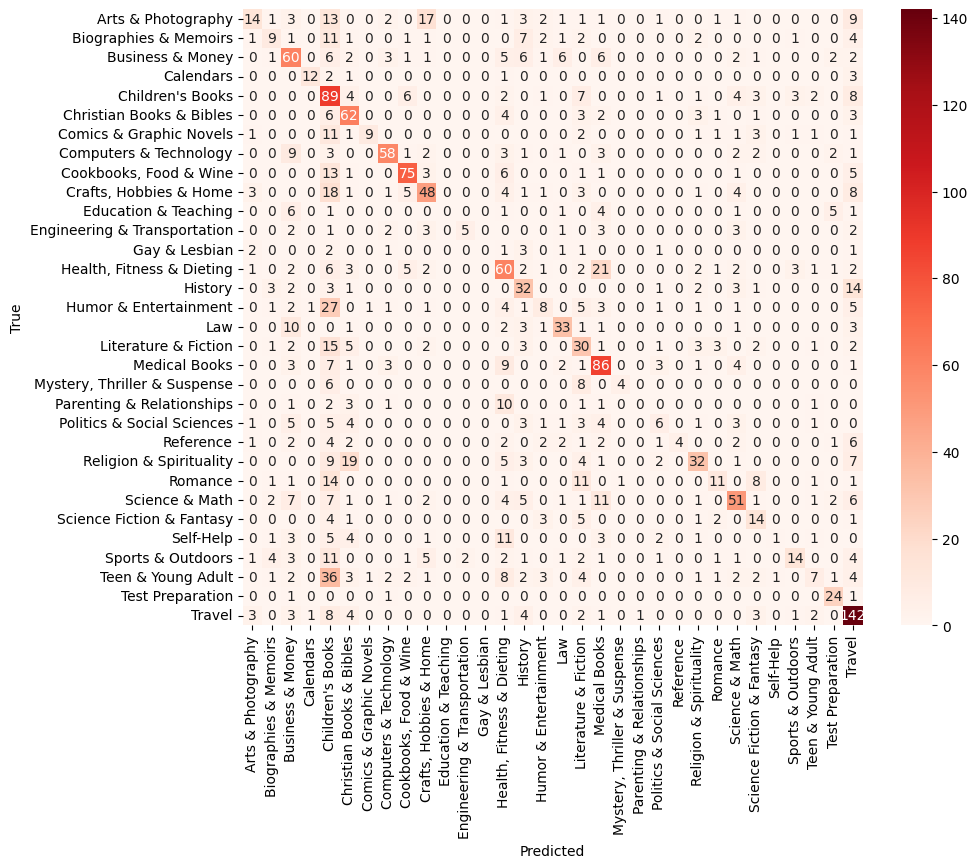

In [ ]:
#confusion matrix for the random tree classifer
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt
from matplotlib import pyplot as plt
import seaborn as sn

cm = confusion_matrix(y_test, RF_predictions)
plt.figure(figsize=(10, 8))
sn.heatmap(cm, annot=True, fmt="d", cmap="Reds",
            xticklabels=encoder.classes_, yticklabels=encoder.classes_)

plt.xlabel("Predicted")
plt.ylabel("True")
plt.show()

In [ ]:
# created a dataset and dataloader
import torch
from torch.utils.data import Dataset, DataLoader
from transformers import DistilBertTokenizer

tokenizer = DistilBertTokenizer.from_pretrained('distilbert-base-uncased')
weights = 'distilbert-base-uncased'
#borrowed code for building the TitleClassificationDataset class from The Medium: https://medium.com/@khang.pham.exxact/text-classification-with-bert-7afaacc5e49b
#Note that the code is adjusted to fit for the problem
class TitleClassificationDataset(Dataset):#preparing the data to use for the BERT model
  def __init__(self, labels, encodings):
      #self.texts = texts
      self.labels = labels.reset_index(drop=True)# resetting the index of label columns
      self.encodings = encodings # stores the encoded feature value
  def __len__(self): #return total number of labels in the dataset
    return len(self.labels)
  def __getitem__(self, idx): # get a datapoint by its index
    item = {key: torch.tensor(val[idx]) for key, val in self.encodings.items()} #convert encodings into pytortch sensors
    item['labels'] = torch.tensor(self.labels[idx])
    return item
#when I tried training on the full dataset the model did not run so im gonna try to run on only 1% of the dataset
df_sampled = df.sample(frac=0.01, random_state=42)
x_train, x_test, y_train, y_test = train_test_split(
    df_sampled['TITLE'], df_sampled['LABEL'], test_size=0.2, random_state=42
)

train_encodings = tokenizer(list(x_train), truncation=True, padding=True, max_length=128) #prepares the training set for BERT by tokenizing it
test_encodings = tokenizer(list(x_test), truncation=True, padding=True, max_length=128)#prepares the test set for BERT by tokenizing it

train_dataset = TitleClassificationDataset(y_train, train_encodings)
test_dataset = TitleClassificationDataset(y_test, test_encodings)
train_data_loader = DataLoader(train_dataset, batch_size=8, shuffle=True)# creates dataloader objects so we are able to split the training and test sets into batches
test_data_loader = DataLoader(test_dataset, batch_size=8, shuffle=True)


/usr/local/lib/python3.11/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

vocab.txt:   0%|          | 0.00/232k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/466k [00:00<?, ?B/s]

config.json:   0%|          | 0.00/483 [00:00<?, ?B/s]

In [ ]:
from transformers import DistilBertForSequenceClassification

num_classes = len(encoder.classes_) #get the number of classes

#def get_model():
    #return DistilBertForSequenceClassification.from_pretrained(weights, num_labels=num_classes)

#model = get_model()
model = DistilBertForSequenceClassification.from_pretrained(weights, num_labels=num_classes) # defined the model as a DistilBERT pretrained model
#uses the version for sequence classification since the we are doing text classification




Xet Storage is enabled for this repo, but the 'hf_xet' package is not installed. Falling back to regular HTTP download. For better performance, install the package with: `pip install huggingface_hub[hf_xet]` or `pip install hf_xet`


model.safetensors:   0%|          | 0.00/268M [00:00<?, ?B/s]

Some weights of DistilBertForSequenceClassification were not initialized from the model checkpoint at distilbert-base-uncased and are newly initialized: ['classifier.bias', 'classifier.weight', 'pre_classifier.bias', 'pre_classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


In [ ]:
from sklearn.metrics import accuracy_score, classification_report
from transformers import DistilBertForSequenceClassification #using this Bert version so I do not have to manually add a output layer.
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

#IMPORTANT: THIS IS THE CODE THAT WAS NOT ABLE TO RUN AT ALL with a higher percentage so I was only able to train the model on 1% of the dataset
#model.to(device)
model.to(device)
predictions = [] #store the predictiond
labels_lst = [] #store the labels

#IMPORTANT: borrwoed some of the code for developeding the evaluation_model function from the same article that used for develeping the text classifcation class from the medium: https://medium.com/@khang.pham.exxact/text-classification-with-bert-7afaacc5e49b
#some of the code is changed to fit for this classification problem
def evaluate_model(model, data_loader): #defined a separate function for evaluting the model for organization purposes
    model.eval()

    with torch.no_grad():
        for batch in data_loader: # go throight each batch
            input_ids = batch['input_ids'].to(device) # send the tokenizes inputs to the CPU
            attention_mask = batch['attention_mask'].to(device) #send the attention mask to the cpu
            batch_labels = batch['labels'].to(device) # send the labels to the CPU
            outputs = model(input_ids=input_ids, attention_mask=attention_mask, labels=batch_labels)
            logits = outputs.logits
            predictions.extend(torch.argmax(logits, dim=1).cpu().numpy())# add to the prediction list
            labels_lst.extend(batch_labels.cpu().numpy()) # add to the labels list
    accuracy = accuracy_score(labels_lst, predictions) #get the accuracy score
    report = classification_report(labels_lst, predictions) #get the classification report

    return accuracy, report #return the accuracy score and the classification report



optimizer = torch.optim.AdamW(model.parameters(), lr=2e-5) #creates an instanc eof a ADAM optimizer
loss_fn = torch.nn.CrossEntropyLoss() # using s crossentropy loss function
epochs = 2 # 3 training epochs
accumulation_steps = 2 # gradients are accumalted 2 steps over
for epoch in range(epochs):
    model.train()
    for i, batch in enumerate(train_data_loader):
        #print(f"Epoch: {epoch}")
        optimizer.zero_grad()
        input_ids = batch['input_ids'].to(device)
        attention_mask = batch['attention_mask'].to(device)
        labels = batch['labels'].to(device)
        outputs = model(input_ids=input_ids, attention_mask=attention_mask, labels=labels)
        loss = outputs.loss / accumulation_steps
        loss.backward()#computes gradient for backward propagation

        if (i + 1) % accumulation_steps == 0: #checks if i is a multiple of 2 to let us know if we shouls update the models parameters,
          optimizer.step()                    #used Google Gemini to implement this logic
          optimizer.zero_grad()

accuracy_score, report = evaluate_model(model, test_data_loader)
print(f"Accuracy: {accuracy_score}")
print(report)



#model.save_pretrained("genre_classification_model") -save model
#tokenizer.save_pretrained("genre_classification_model")

Accuracy: 0.33653846153846156
              precision    recall  f1-score   support

           0       0.00      0.00      0.00        16
           1       0.00      0.00      0.00        13
           2       0.60      0.67      0.63        18
           3       0.00      0.00      0.00         5
           4       0.15      0.50      0.23        20
           5       0.25      0.64      0.36        14
           6       0.00      0.00      0.00         5
           7       0.44      0.80      0.57        20
           8       0.88      0.88      0.88        16
           9       0.75      0.15      0.25        20
          10       0.00      0.00      0.00         3
          11       0.00      0.00      0.00         4
          12       0.00      0.00      0.00         3
          13       0.26      0.73      0.38        22
          14       0.00      0.00      0.00         7
          15       0.00      0.00      0.00        11
          16       0.59      0.67      0.62        

/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


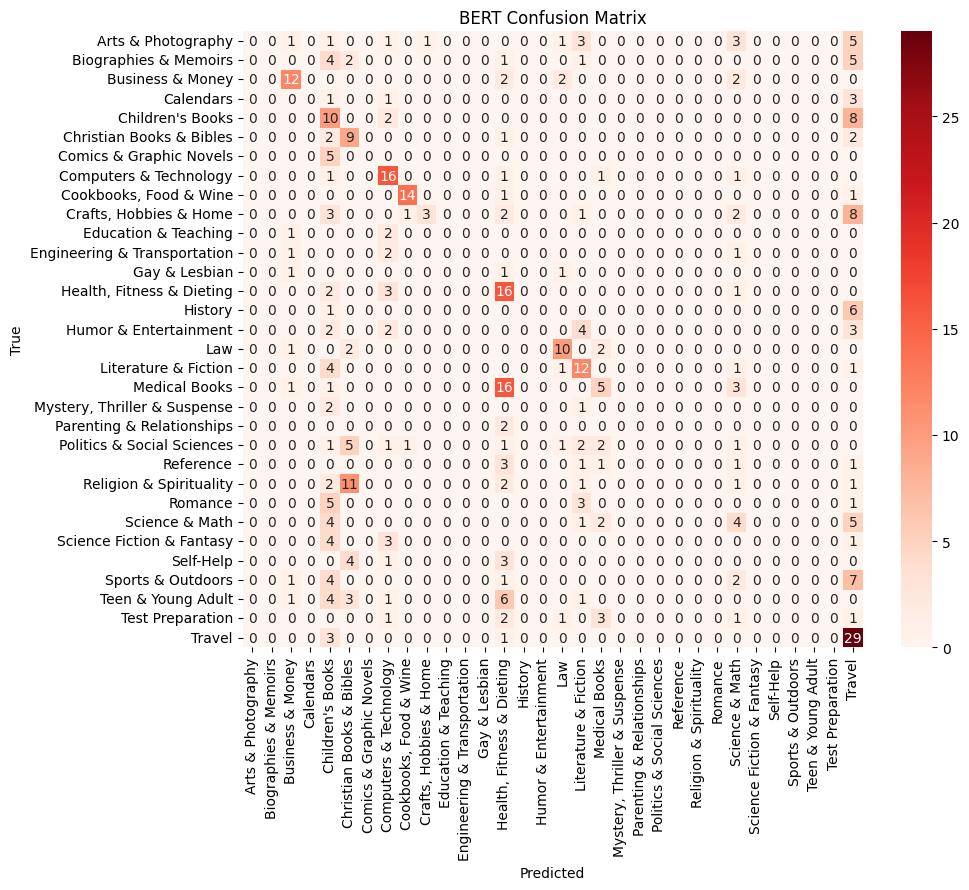

In [ ]:
#confusion matrix
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt
from matplotlib import pyplot as plt
import seaborn as sn

cm = confusion_matrix(labels_lst, predictions)

plt.figure(figsize=(10, 8))
sn.heatmap(cm, annot=True, fmt="d", cmap="Reds",
            xticklabels=encoder.classes_, yticklabels=encoder.classes_)

plt.xlabel("Predicted")
plt.ylabel("True")
plt.title("BERT Confusion Matrix")
plt.show()

